In [2]:
import os
print(f"Current Directory: {os.getcwd()}")
os.chdir("..")
print(f"New Directory: {os.getcwd()}")

Current Directory: c:\Users\mattc\Documents\DL-reservoir-modeling\reviewer_comments
New Directory: c:\Users\mattc\Documents\DL-reservoir-modeling


In [3]:
import pandas as pd
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
RESULT_DIR = 'report/results/reviewer_comments/alternative_metrics'
LOWER_QUANTILE = 0.90
MODEL_ORDER = [
    'LSTM Model 1',
    'LSTM Model 1-S',
    'LSTM Model 2',
    'LSTM Model 3',
    'RNN Model 4',
    'Random Forest Model-S',
    'Linear Model-S',
    'Rule-Based Model',
    'Model 1-S (sim storage input)',
]

### Figure helper functions

In [35]:
def get_percentile_labels(lower_quantile):
    """
    Create readable labels for the lower and upper percentile groups.
    """
    lower_percent = int(round(lower_quantile * 100))
    upper_percent = 100 - lower_percent
    return lower_percent, upper_percent, f'bottom {lower_percent}%', f'top {upper_percent}%'


def clip_axis_to_percentiles(ax, values, quantile):
    """
    Clip extreme outliers so the boxplots remain readable.
    """
    y_lo = values.quantile(quantile)
    y_hi = values.quantile(1-quantile)
    y_pad = 0.05 * (y_hi - y_lo) if y_hi > y_lo else 1
    ax.set_ylim(y_lo - y_pad, y_hi + y_pad)


def load_metric_frames(metric_name):
    """
    Load model-family metric csvs and return a single long-format dataframe.
    Params:
    metric_name -- str, one of {'pbias', 'rmse', 'r2'}. r2 will load frames from main results.
    Returns:
    df_all -- concatenated long-format dataframe
    """
    if metric_name == 'r2':
        r2_result_dir = 'report/results/resops_training/'
        metric_files = [
            ('', 'LSTM Model 1', f'{r2_result_dir}/resops_individual_r2.csv'),
            ('', 'LSTM Model 1-S', f'{r2_result_dir}/resops_benchmark_lstm_w_storage_r2.csv'),
            ('', 'LSTM Model 2', f'{r2_result_dir}/resops_unroll_models/resops_unroll_model2_r2.csv'),
            ('', 'LSTM Model 3', f'{r2_result_dir}/resops_unroll_models/resops_unroll_model3_r2.csv'),
            ('', 'RNN Model 4', f'{r2_result_dir}/resops_unroll_models/resops_unroll_model4_r2.csv'),
            ('', 'Random Forest Model-S', f'{r2_result_dir}/resops_benchmark_rf_r2.csv'),
            ('', 'Linear Model-S', f'{r2_result_dir}/resops_benchmark_linear_r2.csv'),
            ('', 'Rule-Based Model', f'{r2_result_dir}/resops_benchmark_rule_based_r2.csv'),
            ('', 'Model 1-S (sim storage input)', f'{r2_result_dir}/resops_model1s_sim_storage_r2.csv'),
        ]
    else:    
        metric_files = [
            ('resops_unroll_model1', 'LSTM Model 1', f'{RESULT_DIR}/resops_unroll_model1_{metric_name}.csv'),
            ('resops_model1S', 'LSTM Model 1-S', f'{RESULT_DIR}/resops_model1S_{metric_name}.csv'),
            ('resops_unroll_model2', 'LSTM Model 2', f'{RESULT_DIR}/resops_unroll_model2_{metric_name}.csv'),
            ('resops_unroll_model3', 'LSTM Model 3', f'{RESULT_DIR}/resops_unroll_model3_{metric_name}.csv'),
            ('resops_unroll_model4', 'RNN Model 4', f'{RESULT_DIR}/resops_unroll_model4_{metric_name}.csv'),
            ('resops_benchmark_random_forest', 'Random Forest Model-S', f'{RESULT_DIR}/resops_benchmark_random_forest_{metric_name}.csv'),
            ('resops_benchmark_linear', 'Linear Model-S', f'{RESULT_DIR}/resops_benchmark_linear_{metric_name}.csv'),
            ('resops_benchmark_rule_based', 'Rule-Based Model', f'{RESULT_DIR}/resops_benchmark_rule_based_{metric_name}.csv'),
            ('resops_model1S_implied', 'Model 1-S (sim storage input)', f'{RESULT_DIR}/resops_model1S_implied_{metric_name}.csv'),
        ]

    frames = []
    for _, model_label, filepath in metric_files:
        df = pd.read_csv(filepath, index_col=0)
        df = df.melt(value_vars=['train', 'val', 'test'])
        df['Model'] = model_label
        frames.append(df)

    df_all = pd.concat(frames, axis=0, ignore_index=True)
    df_all['Model'] = pd.Categorical(df_all['Model'], categories=MODEL_ORDER, ordered=True)
    return df_all


def load_percentile_metric_frames(metric_name, lower_quantile=LOWER_QUANTILE):
    """
    Load percentile-split alternative metric csvs and return a single long-format dataframe.
    """
    lower_pct, upper_pct, lower_label, upper_label = get_percentile_labels(lower_quantile)

    metric_files = [
        ('LSTM Model 1', f'{RESULT_DIR}/resops_unroll_model1_{metric_name}_bottom{lower_pct}.csv', f'{RESULT_DIR}/resops_unroll_model1_{metric_name}_top{upper_pct}.csv'),
        ('LSTM Model 1-S', f'{RESULT_DIR}/resops_model1S_{metric_name}_bottom{lower_pct}.csv', f'{RESULT_DIR}/resops_model1S_{metric_name}_top{upper_pct}.csv'),
        ('LSTM Model 2', f'{RESULT_DIR}/resops_unroll_model2_{metric_name}_bottom{lower_pct}.csv', f'{RESULT_DIR}/resops_unroll_model2_{metric_name}_top{upper_pct}.csv'),
        ('LSTM Model 3', f'{RESULT_DIR}/resops_unroll_model3_{metric_name}_bottom{lower_pct}.csv', f'{RESULT_DIR}/resops_unroll_model3_{metric_name}_top{upper_pct}.csv'),
        ('RNN Model 4', f'{RESULT_DIR}/resops_unroll_model4_{metric_name}_bottom{lower_pct}.csv', f'{RESULT_DIR}/resops_unroll_model4_{metric_name}_top{upper_pct}.csv'),
        ('Random Forest Model-S', f'{RESULT_DIR}/resops_benchmark_random_forest_{metric_name}_bottom{lower_pct}.csv', f'{RESULT_DIR}/resops_benchmark_random_forest_{metric_name}_top{upper_pct}.csv'),
        ('Linear Model-S', f'{RESULT_DIR}/resops_benchmark_linear_{metric_name}_bottom{lower_pct}.csv', f'{RESULT_DIR}/resops_benchmark_linear_{metric_name}_top{upper_pct}.csv'),
        ('Rule-Based Model', f'{RESULT_DIR}/resops_benchmark_rule_based_{metric_name}_bottom{lower_pct}.csv', f'{RESULT_DIR}/resops_benchmark_rule_based_{metric_name}_top{upper_pct}.csv'),
        ('Model 1-S (sim storage input)', f'{RESULT_DIR}/resops_model1S_implied_{metric_name}_bottom{lower_pct}.csv', f'{RESULT_DIR}/resops_model1S_implied_{metric_name}_top{upper_pct}.csv'),
    ]

    frames = []
    for model_label, lower_path, upper_path in metric_files:
        lower_df = pd.read_csv(lower_path, index_col=0).melt(value_vars=['train', 'val', 'test'])
        lower_df['Percentile Range'] = lower_label
        lower_df['Model'] = model_label

        upper_df = pd.read_csv(upper_path, index_col=0).melt(value_vars=['train', 'val', 'test'])
        upper_df['Percentile Range'] = upper_label
        upper_df['Model'] = model_label

        frames.extend([lower_df, upper_df])

    df_all = pd.concat(frames, axis=0, ignore_index=True)
    df_all['Model'] = pd.Categorical(df_all['Model'], categories=MODEL_ORDER, ordered=True)
    return df_all


def make_metric_figure(metric_name, ylabel=None, filename=None, clip_quantile=0.02, ax=None):
    """
    Create and save one boxplot figure for a given metric.
    """
    export_fig = False
    df_metric = load_metric_frames(metric_name=metric_name)

    if ax is None:
        fig, ax = plt.subplots()
        export_fig = True

    sns.boxplot(data=df_metric, x='variable', y='value', hue='Model', hue_order=MODEL_ORDER, ax=ax)

    if clip_quantile:
        clip_axis_to_percentiles(ax=ax, values=df_metric['value'], quantile=clip_quantile)

    if export_fig:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend_.remove()
        legend = fig.legend(
            handles,
            labels,
            loc='lower center',
            bbox_to_anchor=(0.5, -0.2),
            ncol=3,
            frameon=True,
            title='Model',
            fontsize='medium',
            title_fontsize='large'
        )
        legend.set_in_layout(True)

        ax.set_title(f'{metric_name.upper()} Performance on Individual ResOps Reservoirs', size='x-large')
        ax.set_ylabel(ylabel, size='x-large')
        ax.set_xlabel('')
        plt.setp(ax.get_xticklabels(), size='x-large')

        plt.tight_layout()
        plt.savefig(f'{RESULT_DIR}/{filename}', dpi=300, bbox_inches='tight')
        plt.close(fig)


def make_percentile_metric_figure(metric_name, ylabel=None, filename=None, set='test', lower_quantile=LOWER_QUANTILE, clip_quantile=0.02, ax=None):
    """
    Create and save one boxplot figure for a percentile-split metric. Set is 'train', 'val', or 'test
    """
    export_fig = False

    _, _, lower_label, upper_label = get_percentile_labels(lower_quantile)
    df_metric = load_percentile_metric_frames(metric_name=metric_name, lower_quantile=lower_quantile)

    if ax is None:
        fig, ax = plt.subplots()
        export_fig = True
    
    sns.boxplot(
        data=df_metric[df_metric['variable'] == set],
        x='Percentile Range',
        y='value',
        hue='Model',
        hue_order=MODEL_ORDER,
        order=[lower_label, upper_label],
        ax=ax
    )

    if clip_quantile:
        clip_axis_to_percentiles(ax=ax, values=df_metric['value'], quantile=clip_quantile)

    if export_fig:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend_.remove()
        legend = fig.legend(
            handles,
            labels,
            loc='lower center',
            bbox_to_anchor=(0.5, -0.2),
            ncol=3,
            frameon=True,
            title='Model',
            fontsize='medium',
            title_fontsize='large'
        )
        legend.set_in_layout(True)

        ax.set_title(f'Percentile-Split {metric_name.upper()} on Individual ResOps {set.title()} Data', size='x-large')
        ax.set_ylabel(ylabel, size='x-large')
        ax.set_xlabel('')
        plt.setp(ax.get_xticklabels(), size='x-large')
        plt.tight_layout()
        plt.savefig(f'{RESULT_DIR}/{filename}', dpi=300, bbox_inches='tight')
        plt.close(fig)

### Create single-metric plots

In [36]:
os.makedirs(RESULT_DIR, exist_ok=True)

make_metric_figure(
    metric_name='pbias',
    ylabel='PBIAS',
    filename='individual_resops_all_benchmarks_pbias.png',
    clip_quantile=0.02
)
make_metric_figure(
    metric_name='rmse',
    ylabel='RMSE',
    filename='individual_resops_all_benchmarks_rmse.png',
    clip_quantile=0.07
)
make_percentile_metric_figure(
    metric_name='pbias',
    ylabel='PBIAS',
    filename='individual_resops_all_benchmarks_percentile_pbias.png',
    lower_quantile=LOWER_QUANTILE,
    clip_quantile=0.01
)
make_percentile_metric_figure(
    metric_name='rmse',
    ylabel='RMSE',
    filename='individual_resops_all_benchmarks_percentile_rmse.png',
    lower_quantile=LOWER_QUANTILE,
    clip_quantile=0.05
)

### Create side-by-side plot

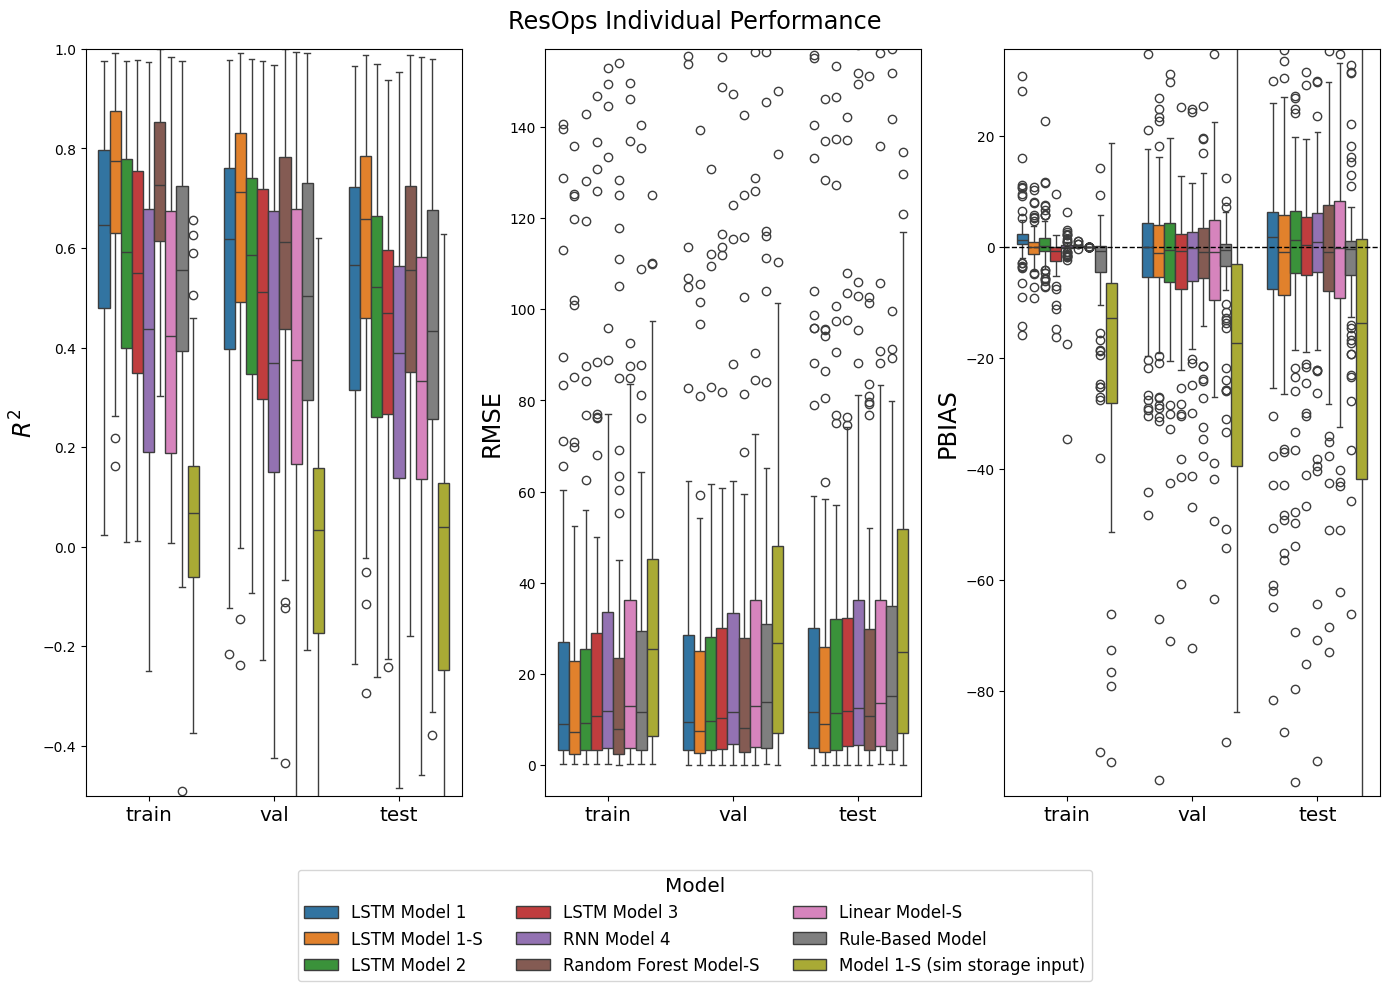

In [37]:
fig, axes = plt.subplots(ncols=3, figsize=(14, 10))

make_metric_figure(metric_name='r2', clip_quantile=None, ax=axes[0])
axes[0].set_ylabel('$R^2$', size='xx-large')
axes[0].set_xlabel('')
axes[0].set_ylim(-0.5, 1)
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend_.remove()

make_metric_figure(metric_name='rmse', clip_quantile=0.07, ax=axes[1])
axes[1].set_ylabel('RMSE', size='xx-large')
axes[1].set_xlabel('')
axes[1].legend_.remove()

make_metric_figure(metric_name='pbias', clip_quantile=0.02, ax=axes[2])
axes[2].axhline(0, color='black', linestyle='--', linewidth=1, label='_nolegend_')
axes[2].set_ylabel('PBIAS', size='xx-large')
axes[2].set_xlabel('')
axes[2].legend_.remove()

fig.suptitle('ResOps Individual Performance', size='xx-large')
fig.legend(
    handles=handles,
    labels=labels,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.0),
    ncol=3,
    frameon=True,
    title='Model',
    fontsize='large',
    title_fontsize='x-large'
)
plt.setp(axes[0].get_xticklabels(), size='x-large')
plt.setp(axes[1].get_xticklabels(), size='x-large')
plt.setp(axes[2].get_xticklabels(), size='x-large')
plt.tight_layout(rect=[0, 0.15, 1, 1])
plt.savefig('report/results/reviewer_comments/alternative_metrics/resops_individual_all_metrics.png', dpi=300)
plt.show()

In [38]:
pbias_df = load_metric_frames(metric_name='pbias')
pbias_df.groupby(['variable', 'Model']).median()

C:\Users\mattc\AppData\Local\Temp\ipykernel_10412\232035910.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pbias_df.groupby(['variable', 'Model']).median()


value
variable Model                                      
test     LSTM Model 1                   1.753000e+00
         LSTM Model 1-S                -9.693232e-01
         LSTM Model 2                   1.165332e+00
         LSTM Model 3                   2.566391e-01
         RNN Model 4                    8.086466e-01
         Random Forest Model-S         -9.609107e-01
         Linear Model-S                -2.958064e-01
         Rule-Based Model              -4.867733e-01
         Model 1-S (sim storage input) -1.376758e+01
train    LSTM Model 1                   1.124264e+00
         LSTM Model 1-S                -1.478803e-01
         LSTM Model 2                   1.024895e-01
         LSTM Model 3                  -7.857775e-01
         RNN Model 4                   -2.490368e-02
         Random Forest Model-S          7.708367e-02
         Linear Model-S                 2.232185e-16
         Rule-Based Model              -7.608902e-01
         Model 1-S (sim storage input) -1.283748e+01
val      LSTM Model 1                  -5.596241e-03
         LSTM Model 1-S                -1.096186e+00
         LSTM Model 2                  -5.572172e-01
         LSTM Model 3                  -7.460130e-01
         RNN Model 4                   -1.854491e-01
         Random Forest Model-S         -9.968674e-01
         Linear Model-S                -9.853297e-01
         Rule-Based Model              -6.515981e-01
         Model 1-S (sim storage input) -1.736079e+01

### Create side-by-side percentile plot

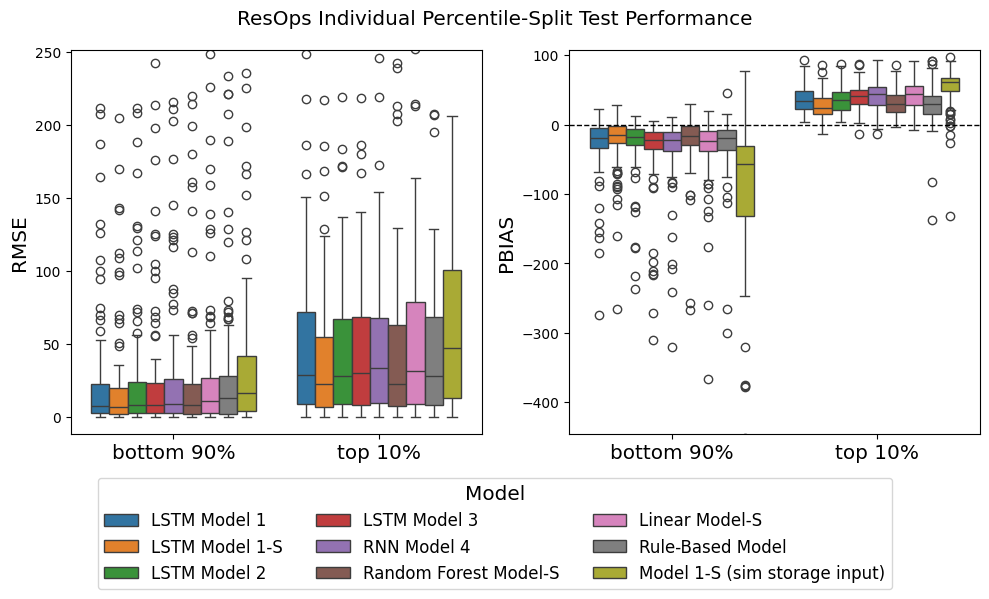

In [43]:
fig, axes = plt.subplots(ncols=2, figsize=(10, 6))

make_percentile_metric_figure(metric_name='rmse', set='test', clip_quantile=0.05, ax=axes[0])
axes[0].set_ylabel('RMSE', size='x-large')
axes[0].set_xlabel('')
axes[0].legend_.remove()
handles, labels = axes[0].get_legend_handles_labels()


make_percentile_metric_figure(metric_name='pbias', set='test', clip_quantile=0.01, ax=axes[1])
axes[1].axhline(0, color='black', linestyle='--', linewidth=1, label='_nolegend_')
axes[1].set_ylabel('PBIAS', size='x-large')
axes[1].set_xlabel('')
axes[1].legend_.remove()

fig.suptitle('ResOps Individual Percentile-Split Test Performance', size='x-large')
fig.legend(
    handles=handles,
    labels=labels,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.0),
    ncol=3,
    frameon=True,
    title='Model',
    fontsize='large',
    title_fontsize='x-large'
)
plt.setp(axes[0].get_xticklabels(), size='x-large')
plt.setp(axes[1].get_xticklabels(), size='x-large')
plt.tight_layout(rect=[0, 0.2, 1, 1])
plt.savefig('report/results/reviewer_comments/alternative_metrics/resops_individual_percentile_metrics.png', dpi=300)
plt.show()

In [53]:
pbias_percentile_df = load_percentile_metric_frames(metric_name='pbias')
pbias_percentile_df[pbias_percentile_df['variable'] == 'test'].drop(columns=['variable']).groupby(['Percentile Range', 'Model'], observed=True).median()

value
Percentile Range Model                                   
bottom 90%       LSTM Model 1                  -19.291054
                 LSTM Model 1-S                -15.207478
                 LSTM Model 2                  -17.595212
                 LSTM Model 3                  -22.855158
                 RNN Model 4                   -22.397733
                 Random Forest Model-S         -16.765657
                 Linear Model-S                -23.500915
                 Rule-Based Model              -19.815243
                 Model 1-S (sim storage input) -56.197796
top 10%          LSTM Model 1                   33.534216
                 LSTM Model 1-S                 23.957819
                 LSTM Model 2                   34.754950
                 LSTM Model 3                   41.180431
                 RNN Model 4                    44.156677
                 Random Forest Model-S          29.777307
                 Linear Model-S                 44.173580
                 Rule-Based Model               29.227329
                 Model 1-S (sim storage input)  60.590004